Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

Load Dataset

In [2]:
df = pd.read_csv("bhatbhateni_sales.csv")

df.head()

,TransactionID,Date,CustomerID,CustomerName,Branch,ProductCategory,ProductName,Quantity,UnitPrice,TotalAmount,PaymentMethod
0,TXN101590,2025-05-19,CUST1100,Sujan Shrestha,Pokhara - Lakeside,Bakery,Chocolate Cake Slice,2,171.29,342.58,Khalti
1,TXN103282,2025-03-07,CUST1005,Milan Lama,Butwal - Traffic Chowk,Personal Care,Dove Soap,3,149.59,448.77,eSewa
2,TXN103539,2025-10-05,CUST1130,Alina Rai,Bhaktapur - Suryabinayak,Apparel,Winter Jacket,4,2794.25,11177.00,Khalti
3,TXN102479,2025-11-12,CUST1057,Neha Karki,Kathmandu - New Road,Household,Surf Excel 1kg,4,399.62,1598.48,Cash
4,TXN104408,2025-10-09,CUST1005,Milan Lama,Butwal - Traffic Chowk,Beverages,Gorkha Beer (6-pack),2,281.01,562.02,eSewa


Basic Information

In [3]:
print("Shape:", df.shape)

print("\nColumns")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nSummary Statistics")
display(df.describe())

Shape: (18812, 11)

Columns
Index(['TransactionID', 'Date', 'CustomerID', 'CustomerName', 'Branch',
       'ProductCategory', 'ProductName', 'Quantity', 'UnitPrice',
       'TotalAmount', 'PaymentMethod'],
      dtype='str')

Data Types
TransactionID          str
Date                   str
CustomerID             str
CustomerName           str
Branch                 str
ProductCategory        str
ProductName            str
Quantity             int64
UnitPrice          float64
TotalAmount        float64
PaymentMethod          str
dtype: object

Summary Statistics


,Quantity,UnitPrice,TotalAmount
count,18812.000000,18441.000000,18812.000000
mean,2.506804,728.803530,1819.990565
std,1.114328,766.346109,2241.968350
min,1.000000,40.140000,40.610000
25%,2.000000,240.160000,488.397500
50%,3.000000,416.780000,989.000000
75%,3.000000,848.320000,2142.545000
max,4.000000,3499.280000,13997.120000


Missing Values

In [4]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": round(df.isnull().mean()*100, 2)
})

display(missing)

,Missing Count,Missing Percentage
TransactionID,0,0.00
Date,0,0.00
CustomerID,0,0.00
CustomerName,568,3.02
Branch,0,0.00
ProductCategory,282,1.50
ProductName,0,0.00
Quantity,0,0.00
UnitPrice,371,1.97
TotalAmount,0,0.00


Duplicate Rows

In [5]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 724


Remove Duplicates

In [6]:
before = len(df)

df = df.drop_duplicates()

after = len(df)

print("Rows Before:", before)
print("Rows After :", after)

Rows Before: 18812
Rows After : 18088


Fill Missing Values

In [7]:
# Customer Name
df["CustomerName"] = df["CustomerName"].fillna("Unknown")

# Payment Method
df["PaymentMethod"] = df["PaymentMethod"].fillna("Unknown")

# Product Category
df["ProductCategory"] = (
    df.groupby("ProductName")["ProductCategory"]
      .transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else "Unknown"))
)

# Unit Price
df["UnitPrice"] = df["UnitPrice"].fillna(
    df["TotalAmount"] / df["Quantity"]
)

df["UnitPrice"] = df["UnitPrice"].fillna(
    df.groupby("ProductCategory")["UnitPrice"]
      .transform("median")
)

Feature Engineering

In [8]:
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.month_name()

df["Weekday"] = df["Date"].dt.day_name()

df["City"] = df["Branch"].str.split("-").str[0].str.strip()

Validate Total Amount

In [9]:
df["CalculatedTotal"] = df["Quantity"] * df["UnitPrice"]

comparison = pd.DataFrame({
    "Original": df["TotalAmount"],
    "Calculated": df["CalculatedTotal"]
})

comparison.head()

,Original,Calculated
0,342.58,342.58
1,448.77,448.77
2,11177.00,11177.00
3,1598.48,1598.48
4,562.02,562.02


Monthly Revenue Trend

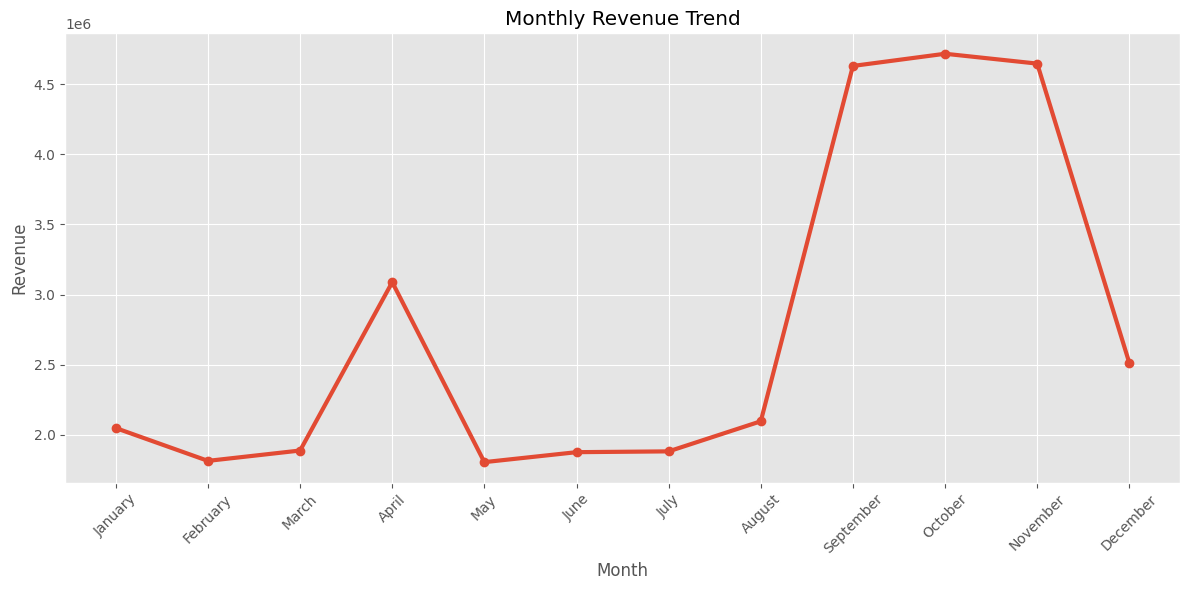

In [10]:
monthly_sales = (
    df.groupby("Month")["TotalAmount"]
      .sum()
      .reindex([
          "January", "February", "March", "April",
          "May", "June", "July", "August",
          "September", "October", "November", "December"
      ])
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=3
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Branch Revenue

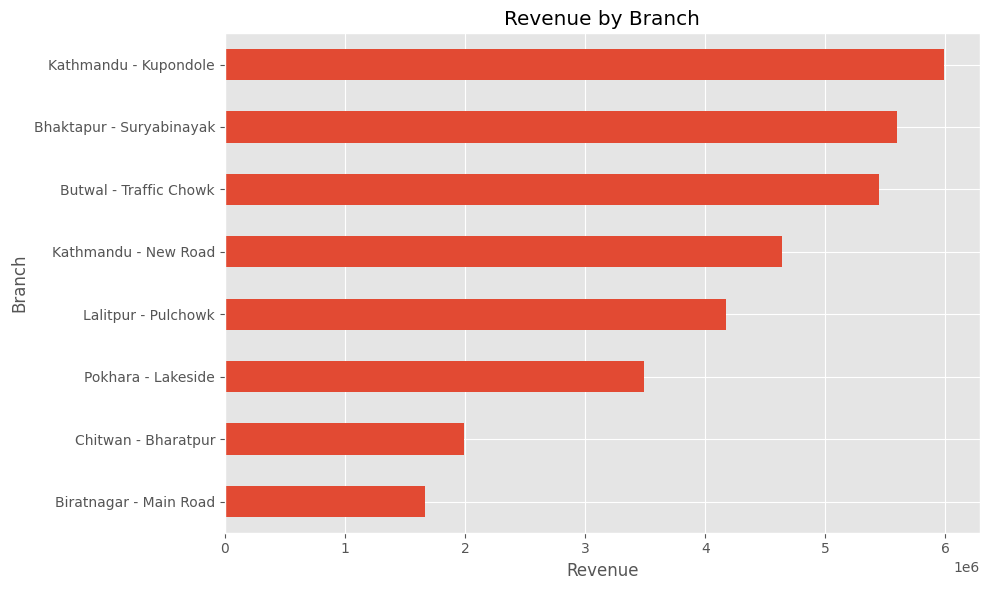

In [11]:
branch_sales = (
    df.groupby("Branch")["TotalAmount"]
      .sum()
      .sort_values()
)

plt.figure(figsize=(10, 6))

branch_sales.plot(kind="barh")

plt.title("Revenue by Branch")

plt.xlabel("Revenue")

plt.tight_layout()

plt.show()

Product Category Revenue

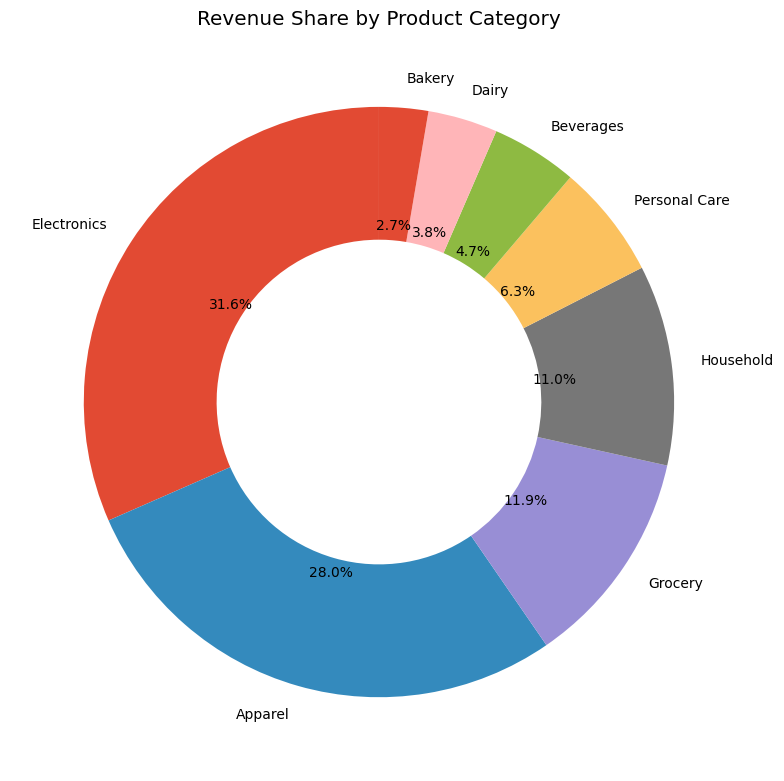

In [12]:
category_sales = (
    df.groupby("ProductCategory")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 8))

plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.45)
)

plt.title("Revenue Share by Product Category")

plt.tight_layout()

plt.show()

Payment Method Distribution

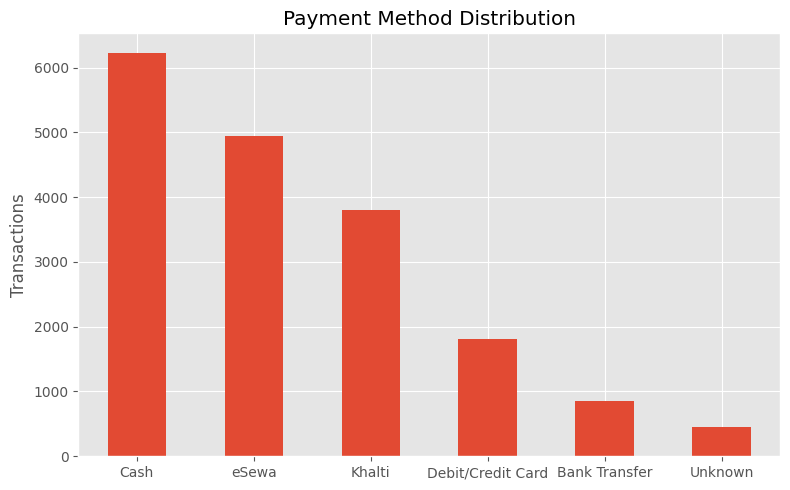

In [13]:
payment = df["PaymentMethod"].value_counts()

plt.figure(figsize=(8, 5))

payment.plot(kind="bar")

plt.title("Payment Method Distribution")

plt.xlabel("")

plt.ylabel("Transactions")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

Top 10 Products

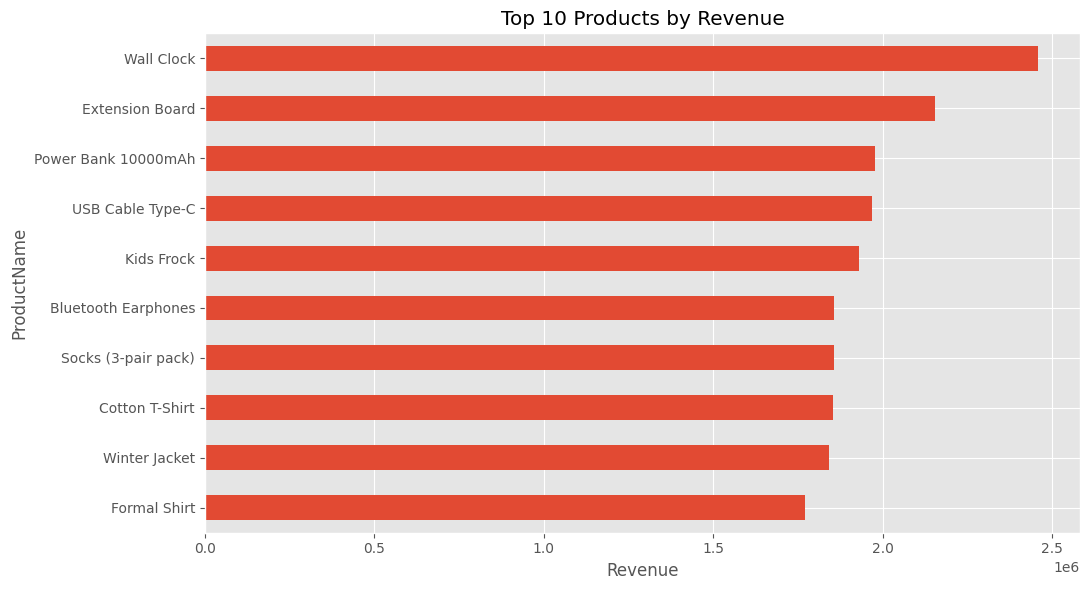

In [14]:
top_products = (
    df.groupby("ProductName")["TotalAmount"]
      .sum()
      .nlargest(10)
      .sort_values()
)

plt.figure(figsize=(11, 6))

top_products.plot(kind="barh")

plt.title("Top 10 Products by Revenue")

plt.xlabel("Revenue")

plt.tight_layout()

plt.show()

Save Clean Dataset

In [15]:
df.to_csv("bhatbhateni_sales_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
